# Local data and pipeline testing

## Making VS Code find Java

In [1]:
!/usr/libexec/java_home -v 17

/opt/homebrew/Cellar/openjdk@17/17.0.20.1/libexec/openjdk.jdk/Contents/Home


In [2]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/Cellar/openjdk@17/17.0.20.1/libexec/openjdk.jdk/Contents/Home"

In [3]:
import os
print(os.environ.get("JAVA_HOME"))
print(os.environ.get("PATH"))

/opt/homebrew/Cellar/openjdk@17/17.0.20.1/libexec/openjdk.jdk/Contents/Home
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/bin:/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/bin:/Users/felipe/.local/bin:/Library/PostgreSQL/18/bin/:/Users/felipe/.pyenv/bin:/Users/felipe/.pyenv/shims:/Users/felipe/.pyenv/bin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/X11/bin:/Library/TeX/texbin:/opt/homebrew/bin:/Applications/quarto/bin:/Applications/Visual Studio Code.app/Contents/Resources/app/bin


## Data size (for Athena scan + AWS storage pricing)

Content length reading script: `check_data_size.sh`.

In [4]:
with open("data_size.txt", "r") as f:
    NBytes = np.sum([
        int(line.split(': ')[1].rstrip('\n'))
        for line in f.readlines()
    ])
    NGB = NBytes / 1024 ** 3
    print(NGB)

NameError: name 'np' is not defined

Byes scanned per query:

In [5]:
import duckdb
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

query = """
SELECT PULocationID, tpep_pickup_datetime, fare_amount
FROM read_parquet('data/yellow_tripdata_2024-*.parquet');
"""
query_analysis = "\n".join(["EXPLAIN ANALYZE", query])


print("".join(con.execute(query_analysis).fetchone()))

df = con.execute(query).df()
print(df.count())



analyzed_plan┌─────────────────────────────────────┐
│┌───────────────────────────────────┐│
││    Query Profiling Information    ││
│└───────────────────────────────────┘│
└─────────────────────────────────────┘
EXPLAIN ANALYZE  SELECT PULocationID, tpep_pickup_datetime, fare_amount FROM read_parquet('data/yellow_tripdata_2024-*.parquet'); 
┌────────────────────────────────────────────────┐
│┌──────────────────────────────────────────────┐│
││              Total Time: 0.0898s             ││
│└──────────────────────────────────────────────┘│
└────────────────────────────────────────────────┘
┌───────────────────────────┐
│           QUERY           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│      EXPLAIN_ANALYZE      │
│    ────────────────────   │
│                           │
│           0 rows          │
│           0.00s           │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         TABLE_SCAN        │
│    ────────────────────   │
│         F

## Basic data query, dataviz

In [6]:
# using cloudfront data link instead of aws for local testing

df = con.execute("""
    SELECT *
    FROM read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet')
    LIMIT 10000
""").df()
print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2024-01-01 00:57:55   2024-01-01 01:17:43                1   
1         1  2024-01-01 00:03:00   2024-01-01 00:09:36                1   
2         1  2024-01-01 00:17:06   2024-01-01 00:35:01                1   
3         1  2024-01-01 00:36:38   2024-01-01 00:44:56                1   
4         1  2024-01-01 00:46:51   2024-01-01 00:52:57                1   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.72           1                  N           186            79   
1           1.80           1                  N           140           236   
2           4.70           1                  N           236            79   
3           1.40           1                  N            79           211   
4           0.80           1                  N           211           148   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \


<Axes: xlabel='PULocationID', ylabel='tip_amount'>

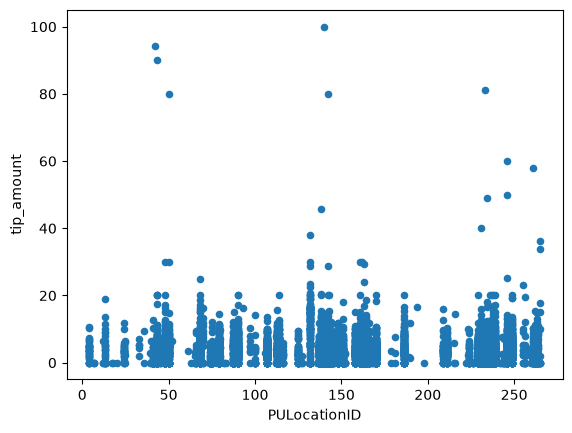

In [7]:
df['pickup_time'] = df.apply(
    axis=1,
    func = lambda row: (
        row.tpep_pickup_datetime.time().hour +
        60 * row.tpep_pickup_datetime.time().minute
    )
)
df[df.fare_amount > 0].plot(x='PULocationID', y='tip_amount', kind='scatter')

## Data wrangling in distributed context test

Data download:
```bash
mkdir -p data
for m in 01 02 03; do
  curl -o data/yellow_tripdata_2024-$m.parquet \
    https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-$m.parquet
done
```

### Read downloaded data

In [8]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("nyc-taxi-local")
    .master("local[*]")          # uses all local cores, no cluster
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

df = spark.read.parquet("data/yellow_tripdata_2024-*.parquet")
df.printSchema()
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/09 14:03:45 WARN Utils: Your hostname, FelimomoBook.local, resolves to a loopback address: 127.0.0.1; using 10.233.127.135 instead (on interface en0)
26/09/09 14:03:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/09 14:03:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/09 14:03:48 WARN Fi

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------

### Data aggregation

In [9]:
from pyspark.sql import functions as F

hourly = (
    df.withColumn("pickup_hour", F.date_trunc("hour", "tpep_pickup_datetime"))
      .groupBy("PULocationID", "pickup_hour")
      .agg(
          F.count("*").alias("trip_count"),
          F.avg("fare_amount").alias("avg_fare"),
          F.std("fare_amount").alias("stdev_fare"),
          F.avg("tip_amount").alias("avg_tip"),
          F.std("tip_amount").alias("stdev_tip"),
      ).withColumn("pickup_hour_only", F.hour("pickup_hour"))
)
hourly.orderBy(F.desc("trip_count")).show(10)

+------------+-------------------+----------+------------------+------------------+------------------+------------------+----------------+
|PULocationID|        pickup_hour|trip_count|          avg_fare|        stdev_fare|           avg_tip|         stdev_tip|pickup_hour_only|
+------------+-------------------+----------+------------------+------------------+------------------+------------------+----------------+
|          79|2024-02-25 01:00:00|       846|14.306690307328607| 8.739821612254802| 2.184290780141844|2.3679796707877374|               1|
|          79|2024-02-25 00:00:00|       803| 14.83493150684932| 8.517835232406473| 2.089265255292653|2.1981751291423146|               0|
|         161|2024-02-29 17:00:00|       779|16.581848523748395|12.380130846086745| 3.557920410783056| 3.166192484219469|              17|
|          79|2024-03-09 01:00:00|       762|14.077152230971127|   8.1784492392139|2.1216272965879286|2.2486053444176894|               1|
|          79|2024-02-25 02

In [10]:
(
    hourly
      .filter("avg_fare <= 100") # filter out outliers
      .filter("avg_tip<=25")
      .plot.scatter(x="avg_fare", y="avg_tip", color="pickup_hour_only")
      .show()
)

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


### Window

In [11]:
from pyspark.sql.window import Window

w = Window.partitionBy("PULocationID").orderBy("pickup_hour")
hourly_with_lag = (
    hourly.withColumn(
        "prev_hour_count", F.lag("trip_count", 1).over(w)
    )
    .withColumn(
        "2prev_hour_count", F.lag("trip_count", 2).over(w)
    ).withColumn(
        "3prev_hour_count", F.lag("trip_count", 3).over(w)
    )
)
hourly_with_lag.show(10)

+------------+-------------------+----------+------------------+------------------+------------------+------------------+----------------+---------------+----------------+----------------+
|PULocationID|        pickup_hour|trip_count|          avg_fare|        stdev_fare|           avg_tip|         stdev_tip|pickup_hour_only|prev_hour_count|2prev_hour_count|3prev_hour_count|
+------------+-------------------+----------+------------------+------------------+------------------+------------------+----------------+---------------+----------------+----------------+
|          12|2024-01-01 00:00:00|         4|           27.7275| 8.275285997071842|             1.625|3.2500000000000004|               0|           NULL|            NULL|            NULL|
|          12|2024-01-01 02:00:00|         1|              20.5|              NULL|               5.1|              NULL|               2|              4|            NULL|            NULL|
|          12|2024-01-01 09:00:00|         3|26.3333333

In [12]:
hourly_with_lag.plot.scatter(
    x="prev_hour_count",
    y="trip_count",
)

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [13]:
hourly_with_lag.plot.scatter(
    x="2prev_hour_count",
    y="trip_count",
)

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [14]:
hourly_with_lag.plot.scatter(
    x="3prev_hour_count",
    y="trip_count",
)


/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [15]:
# Pearson correlations

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# 0. drop NA for VectorAssembler
hourly_with_lag=hourly_with_lag.dropna(
    subset=[
        "trip_count", 
        "prev_hour_count", 
        "2prev_hour_count",
        "3prev_hour_count",
    ]
)

# 1. Prepare your data into a feature vector
assembler = VectorAssembler(inputCols=["trip_count", "prev_hour_count"], outputCol="features")
vector_df = assembler.transform(hourly_with_lag)


# 2. Compute the Pearson correlation matrix
matrix = Correlation.corr(vector_df, "features").head()[0]

# # 3. Extract the correlation value and square it to get R2
r_value = float(matrix[0, 1])
r2_value = r_value ** 2

print(f"count vs lag-1 count R2 Value: {r2_value}")

count vs lag-1 count R2 Value: 0.901821686684693


In [16]:
# Pearson correlations

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# 1. Prepare your data into a feature vector
assembler = VectorAssembler(inputCols=["trip_count", "2prev_hour_count"], outputCol="features")
vector_df = assembler.transform(hourly_with_lag)


# 2. Compute the Pearson correlation matrix
matrix = Correlation.corr(vector_df, "features").head()[0]

# # 3. Extract the correlation value and square it to get R2
r_value = float(matrix[0, 1])
r2_value = r_value ** 2

print(f"count vs lag-2 count R2 Value: {r2_value}")

count vs lag-2 count R2 Value: 0.7660026001391591


In [17]:
# Pearson correlations

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# 1. Prepare your data into a feature vector
assembler = VectorAssembler(inputCols=["trip_count", "3prev_hour_count"], outputCol="features")
vector_df = assembler.transform(hourly_with_lag)


# 2. Compute the Pearson correlation matrix
matrix = Correlation.corr(vector_df, "features").head()[0]

# # 3. Extract the correlation value and square it to get R2
r_value = float(matrix[0, 1])
r2_value = r_value ** 2

print(f"count vs lag-3 count R2 Value: {r2_value}")

count vs lag-3 count R2 Value: 0.6276634936332406


### Revenue as fn of previous trip count

In [18]:
hourly_with_lag = (
    hourly_with_lag
    .withColumn("total_revenue", F.col("avg_fare") * F.col("trip_count"))
)

hourly_with_lag.plot.scatter(x="prev_hour_count", y="total_revenue")

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## ML

In [19]:
# count rows to estimate computational complexity:

hourly_with_lag.count()


240160

### Ridge regression

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge

In [21]:
feature_cols = ["prev_hour_count", "2prev_hour_count", "3prev_hour_count"] 
label_col = "trip_count"

kr_df = hourly_with_lag.select(feature_cols + [label_col]).dropna().toPandas()

kr_df = kr_df.sample(5000) # for local testing

X = kr_df[feature_cols].values
y = kr_df[label_col].values
print(len(y))

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


5000


In [22]:
kr_model = KernelRidge(kernel="rbf", alpha=1.0)
kr_model.fit(X, y)

,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",'rbf'
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1.0
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",None
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None
Name,Type,Value
"X_fit_ X_fit_: {ndarray, sparse matrix} of shape (n_samples, n_features)Training data, which is also required for prediction. Ifkernel == ""precomputed"" this is instead the precomputedtraining matrix, of shape (n_samples, n_samples).","ndarray[int64](5000, 3)","[[ 8, 4, 13], [156,123,120], [ 89, 33, 15], ..., [ 84, 60, 65], [ 2, 1, 2], [ 17, 22, 61]]"
"dual_coef_ dual_coef_: ndarray of shape (n_samples,) or (n_samples, n_targets)Representation of weight vector(s) in kernel space","ndarray[float64](5000,)","[28.1 ,90. ,82. ,...,31. ,-0.36, 3.47]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3


In [23]:
import numpy as np

kr_model.predict(np.array([[5,3,2], [7,4,9]]))

array([5.11186284, 9.4101015 ])

In [24]:
kr_test_df = hourly_with_lag.select(feature_cols + [label_col]).dropna().toPandas()

kr_test_df = kr_test_df.sample(1000)

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [25]:
kr_test_df[feature_cols].to_numpy()

array([[181, 167, 198],
       [163, 144, 127],
       [  2,   1,   1],
       ...,
       [163, 160, 136],
       [ 62,  37,  20],
       [146, 152, 265]], shape=(1000, 3))

In [26]:
from sklearn.metrics import mean_squared_error

kr_test_df['prediction'] = (
    kr_model.predict(kr_test_df[feature_cols].to_numpy())
)

mse = mean_squared_error(kr_test_df['trip_count'], kr_test_df['prediction'])

print(f"Kernel Ridge mse: {mse}")

Kernel Ridge mse: 7046.703200352318


### XGBoost

In [27]:
from xgboost.spark import SparkXGBRegressor
xgb_regressor = SparkXGBRegressor(
  features_col=["prev_hour_count","2prev_hour_count", "3prev_hour_count"],
  label_col="trip_count",
  num_workers=8,
)

In [28]:
# sample small training and testing datasets
xgb_train_df = hourly_with_lag.sample(0.04)
xgb_test_df_with_gt = hourly_with_lag.sample(0.01).withColumn("ground_truth", F.col("trip_count"))

xgb_test_df = xgb_test_df_with_gt.select(
    [col for col in xgb_test_df_with_gt.columns if col != "trip_count"]
)
print(f"{xgb_train_df.count()}, {xgb_test_df.count()}")

9596, 2330


In [29]:
xgb_test_df.columns

['PULocationID',
 'pickup_hour',
 'avg_fare',
 'stdev_fare',
 'avg_tip',
 'stdev_tip',
 'pickup_hour_only',
 'prev_hour_count',
 '2prev_hour_count',
 '3prev_hour_count',
 'total_revenue',
 'ground_truth']

In [30]:
model = xgb_regressor.fit(xgb_train_df);

2026-09-09 14:04:21,694 INFO XGBoost-PySpark: _fit Running xgboost-3.4.1 on 8 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/functions.py:777: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
2026-09-09 14:04:27,118 INFO XGBoost-PySpark: _train_booster Training on CPUs 8]
[14:04:28] Task 5 got rank 5
[14:04:28] Task 3 got rank 3[14:04:28] Task 7 got rank 7

[14:04:28] Task 1 got rank 1
[14:04:28] Task 2 got rank 2
[14:04:28] Task 6 got rank 6
[14:04:28] Task 4 got rank 4
[14:04:28] Task 0 got rank 0
[14:04:28] [0]	training-rmse:54.77651
[14:04:28] [1]	training-rmse:41.37813
[14:04:28] [2

In [31]:
prediction = model.transform(xgb_test_df)

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/typehints.py:60: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [32]:
prediction.show()

+------------+-------------------+------------------+------------------+------------------+------------------+----------------+---------------+----------------+----------------+------------------+------------+------------------+
|PULocationID|        pickup_hour|          avg_fare|        stdev_fare|           avg_tip|         stdev_tip|pickup_hour_only|prev_hour_count|2prev_hour_count|3prev_hour_count|     total_revenue|ground_truth|        prediction|
+------------+-------------------+------------------+------------------+------------------+------------------+----------------+---------------+----------------+----------------+------------------+------------+------------------+
|          12|2024-01-04 12:00:00|              21.9|13.400932803353653|               3.1| 3.225306187015428|              12|              3|               2|               1|             109.5|           5| 2.747450113296509|
|          12|2024-01-25 16:00:00|             18.92| 5.336215887686704|2.5533333333

2026-09-09 14:04:31,534 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


In [33]:
mse_result = prediction.agg(F.mean((F.col("ground_truth") - F.col("prediction")) ** 2).alias("mse")).collect()
mse = mse_result[0]["mse"]

print(f"XGBoost mse: {mse}")

XGBoost mse: 569.0182169349977


2026-09-09 14:04:32,816 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


## Benchmarking train time

SageMaker pricing depends on wall-time, not total CPU time. Test different number of jobs (thinking 1 job per CPU) and different number of rows to get a table:

| runtime (s) | job-count | instance price |
|-------------|--------------|----------------|
| ... | ... | ... |
| ... | ... | ... |

For more control on the output, I fix the number of estimators (trees) and max tree depth.


In [74]:
import time

SAMPLE_FRACTIONS = [0.01, 0.02, 0.04, 0.08, 0.16, 0.24, 0.32, 0.40]

train_df_dict = {
    sample_frac: (
        hourly_with_lag
            .select([*feature_cols, label_col])
            .sample(sample_frac)
            .toPandas()
    )
    for sample_frac in SAMPLE_FRACTIONS
}
X_dict = {
    sample_frac: train_df_dict[sample_frac][feature_cols].to_numpy()
    for sample_frac in SAMPLE_FRACTIONS
}
y_dict = {
    sample_frac: train_df_dict[sample_frac][[label_col]].to_numpy()
    for sample_frac in SAMPLE_FRACTIONS
}

print(X_dict[SAMPLE_FRACTIONS[0]].shape)
print(y_dict[SAMPLE_FRACTIONS[0]].shape)

/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/felipe/Desktop/Coding/aws-nyc-taxi/.venv/lib/python3.13/site-packages/pyspark/sql

(2385, 3)
(2385, 1)


In [75]:
import xgboost as xgb
import pandas as pd
# data structure 'n_rows', 'n_jobs', 'wall_runtime', 'sage_instance', 'instance_price'
benchmark_data = []

# let's use 8GiB instances that are close to the 8GB of ram 
# available locally
instances = {
    2: 'sc.t3.large',
    4: 'sc.t3.xlarge',
    8: 'sc.t3.2xlarge',
}
prices = { # USD
    2: 0.1,
    4: 0.2,
    8: 0.399,
}

for n_jobs in [2, 4]:
    for sample_frac in SAMPLE_FRACTIONS:
        X = X_dict[sample_frac]
        y = y_dict[sample_frac]
        start = time.time()
        model = xgb.XGBRegressor(n_estimators=200, max_depth=6, n_jobs=n_jobs)
        model.fit(X, y)  
        runtime = time.time() - start
        benchmark_data.append([
            y.shape[0], n_jobs, runtime, instances[n_jobs], prices[n_jobs],
        ])
        print(
            f"n_jobs={n_jobs}, price={prices[n_jobs]}, "
            f"runtime={runtime:.1f}s"
        )

benchmark_df = pd.DataFrame(
    benchmark_data,
    columns=[
        'n_rows', 'n_jobs', 'wall_runtime', 
        'sage_instance', 'instance_price'
    ]
)

n_jobs=2, price=0.1, runtime=0.1s
n_jobs=2, price=0.1, runtime=0.1s
n_jobs=2, price=0.1, runtime=0.1s
n_jobs=2, price=0.1, runtime=0.1s
n_jobs=2, price=0.1, runtime=0.2s
n_jobs=2, price=0.1, runtime=0.2s
n_jobs=2, price=0.1, runtime=0.2s
n_jobs=2, price=0.1, runtime=0.3s
n_jobs=4, price=0.2, runtime=0.1s
n_jobs=4, price=0.2, runtime=0.1s
n_jobs=4, price=0.2, runtime=0.1s
n_jobs=4, price=0.2, runtime=0.2s
n_jobs=4, price=0.2, runtime=0.2s
n_jobs=4, price=0.2, runtime=0.2s
n_jobs=4, price=0.2, runtime=0.2s
n_jobs=4, price=0.2, runtime=0.2s


In [76]:
benchmark_df['runtime_price'] = benchmark_df.apply(
    axis=1,
    func = lambda row: row.instance_price * row.wall_runtime
)

In [77]:
benchmark_df.sort_values(by='n_rows').head()

,n_rows,n_jobs,wall_runtime,sage_instance,instance_price,runtime_price
0,2385,2,0.109343,sc.t3.large,0.1,0.010934
8,2385,4,0.117907,sc.t3.xlarge,0.2,0.023581
1,4706,2,0.111381,sc.t3.large,0.1,0.011138
9,4706,4,0.127537,sc.t3.xlarge,0.2,0.025507
2,9454,2,0.126503,sc.t3.large,0.1,0.012650


<Axes: xlabel='n_rows', ylabel='runtime_price'>

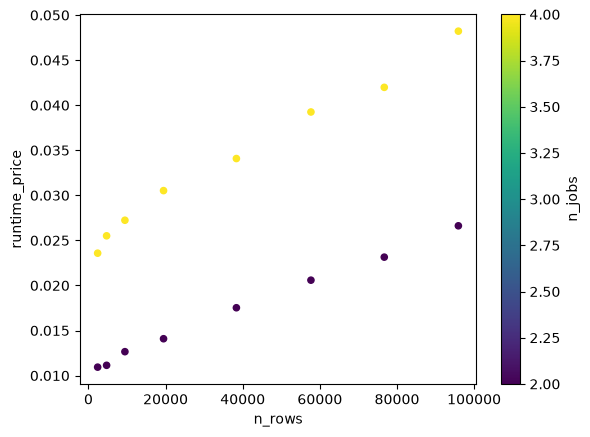

In [78]:
benchmark_df.plot(
    x = 'n_rows',
    y = 'runtime_price',
    c = 'n_jobs',
    cmap = 'viridis',
    kind='scatter'
)

In [ ]:
# linear regression

from sklearn.linear_model import LinearRegression

X_nj2 = np.array([
    [x]
    for x in benchmark_df[benchmark_df['n_jobs']==2].n_rows.to_numpy()
])
y_nj2 = benchmark_df[benchmark_df['n_jobs']==2].runtime_price.to_numpy()

X_nj4 = np.array([
    [x]
    for x in benchmark_df[benchmark_df['n_jobs']==4].n_rows.to_numpy()
])
y_nj4 = benchmark_df[benchmark_df['n_jobs']==4].runtime_price.to_numpy()

reg_nj2 = LinearRegression().fit(X_nj2, y_nj2)
reg_nj4 = LinearRegression().fit(X_nj4, y_nj4)

In [86]:
print(f"2 job full-scale price estimate: ${reg_nj2.predict([[1]])[0]:.2f}")
print(f"2 job full-scale price estimate: ${reg_nj4.predict([[1]])[0]:.2f}")

2 job full-scale price estimate: $0.01
2 job full-scale price estimate: $0.02
